In [1]:
import sys
import os
import numpy as np
import matplotlib.pylab as plt
import uproot
import awkward as ak
import seaborn
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.special import gamma
from scipy.stats import skew
import json



# define the path to mother directory F-CAL-TB to use files in it
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
os.chdir(project_root)

import RA_funcs as rf
import Scope_funcs as sf


imports work
imports work


In [2]:
plt.rcParams.update({
    'font.size': 14,          # Default font size
    'axes.titlesize': 16,     # Title font size
    'axes.labelsize': 14,     # X and Y label font size
    'xtick.labelsize': 11,    # X-axis tick label size
    'ytick.labelsize': 11,    # Y-axis tick label size
    'legend.fontsize': 12     # Legend font size
})


<span style="font-family: Comic Sans MS; font-size:15px; color:Purple">

# Functions

In [3]:
 # sigmoid
def sigmoid_linear(x, A, t, r):
    return  A / (1.0 + np.exp(-(x - t) * r))

In [4]:
# determine the accurate position on the sensor using telescope angles
def position_on_plane(data, dz):
    """calculates the xy values of the particle at a given z
    the xy from the telescope are the xy on plane 0"""

    # position at plane 0
    x0, y0 = data.tele.x, data.tele.y

    # return original scope values if on plane 0
    if dz == 0:
        return x0, y0
    
    # momentum
    px, py, pz = data.tele.px, data.tele.py, data.tele.pz

    # calculate x,y 
    def r_of_z(pr,r0,pz):
        r = (pr/pz)*dz + r0
        return r
    
    x = r_of_z(px,x0,pz)
    y = r_of_z(py,y0,pz)

    return x, y



# convert the plane number to its z distance from plane 0
def planes_to_dz_tracker_mode(plane):
    dz = 4.7*(plane*2 - 1) if plane > 0 else 0 
    return dz

In [5]:
# edges of the pads in the sensor
def pads_to_xy_gridlines(pad_number, pitch=5.53):
    "returns the coordinates of the edges of a pad, pitch is the size of the pad"

    # convert pad number to row and column position
    row = pad_number // 20
    col = pad_number % 20

    # convert the row col to l(tower index) m(x) n(y) coordinates
    l = 1 if col >= 12 else 0
    m = 4 + col - (16 * l)
    n = 3 + row

    # convert (l,m,n) to xy of pad center on the sensor
    x_center = -(86.575 - (5.53 * m) - (90.2 * l))
    y_center = -41.475 + (5.53 * n)
    
    # get the line of the pads edges
    x_left = round(x_center - pitch / 2, 6)  # Left edge
    x_right = round(x_center + pitch / 2, 6)  # Right edge
    y_left = round(y_center - pitch / 2, 6)  # Bottom edge
    y_right = round(y_center + pitch / 2, 6)  # Top edge

    x_lines = [x_left,x_right]
    y_lines = [y_left,y_right]

    return x_lines, y_lines



def multiple_pad_edges_gridlines(pad_list):
    "returns a list of the coordinates of all x and y edges of the pads"

    # change int to list on case given a single pad
    if type(pad_list) == int:
        pad_list = [pad_list]
    
    # get the borders for each pad into a list
    x_lines_list = []
    y_lines_list = []
    for pad in pad_list:
        # edges of the pad
        x_lines_pad, y_lines_pad = pads_to_xy_gridlines(pad)
        # add left and right edges to the list
        x_lines_list.append(x_lines_pad[0]) # left edge
        x_lines_list.append(x_lines_pad[1]) # right edge
        y_lines_list.append(y_lines_pad[0]) # left edge
        y_lines_list.append(y_lines_pad[1]) # right edge

    # discard duplicate values
    x_lines = np.unique(x_lines_list)
    y_lines = np.unique(y_lines_list)

    return x_lines, y_lines

In [6]:
# colormap of the average showeer energy for its scope position
def avg_energy_scope_colormap(data, plane, x_center=0, x_borders="false", y_center=0, y_borders="false", cmap="tab20c", bins=300, pad=True, channels_borders = "all"):

    # calculate the x and y of the particels in the wanted plane
    dz = planes_to_dz_tracker_mode(plane)
    x,y = position_on_plane(data, dz)

    X_scope1 = ak.flatten(x)
    Y_scope1 = ak.flatten(y)

    X_scope = -ak.to_numpy(X_scope1)
    Y_scope = ak.to_numpy(Y_scope1)

    if pad:
        amp1 = ak.sum(data.hits.amp[data.hits.plane == plane], axis = 1)
    if pad != True:
        print(amp1)
        amp1 = ak.sum(data.hits.amp[(data.hits.plane == plane) & (data.hits.ch == pad)], axis =1)

    # amp1 = ak.sum(data.hits.amp, axis = 1)
    amp = ak.to_numpy(amp1)

    # Histogram of SUM of amplitudes
    sum_amp, xedges, yedges = np.histogram2d(X_scope, Y_scope, bins=bins, weights=amp)

    # Histogram of COUNTS
    counts, _, _ = np.histogram2d(X_scope, Y_scope, bins=[xedges, yedges])

    # Avoid division by zero
    avg_amp = np.divide(sum_amp, counts, out=np.zeros_like(sum_amp), where=counts > 0)

    # Plot
    plt.figure(figsize=(6,5))
    plt.pcolormesh(xedges, yedges, avg_amp.T, cmap=cmap)  
    plt.colorbar(label="Average Amplitude")
    plt.xlim(min(X_scope), max(X_scope))
    plt.ylim(min(Y_scope), max(Y_scope))

    if channels_borders == "all":
        pads_list = np.arange(0,256,1)

    # draw vertical lines of the pad edges
    x_lines, _ = multiple_pad_edges_gridlines(pads_list)
    [plt.axvline(x, color='black', linestyle='--', linewidth=0.5, label=f"pad {pad} edge") for x in x_lines]
    _, y_lines = multiple_pad_edges_gridlines(pads_list)
    [plt.axhline(y, color='black', linestyle='--', linewidth=0.5, label=f"pad {pad} edge") for y in y_lines]
    
    
    if x_borders != "false":
        plt.xlim(x_center - x_borders, x_center + x_borders)
    if y_borders != "false":
        plt.ylim(y_center - y_borders, y_center + y_borders)
    
    plt.xlabel("x [mm]")
    plt.ylabel("y [mm]")
    # plt.title(f"Average Shower Energy per Position, pad = {pad}")
    plt.title(f"Average Shower Energy per Position")
    plt.show()


In [7]:
# plots the energy profile vs the x axis and fits to sigmoid without linear
def E_vs_X_scope_sigmoid(hit_data, chi2, plane, y_min=-10, y_max=10, x_min=-20, x_max=20, bin_size = 0.4, return_param=False, pad=True, low_E = 0.02, edges=True, ytext=0.26, return_perr=False):

    # filter data by chi2
    hit_data_chi2 = sf.filter_chi2_scope_data(hit_data, 1/chi2, chi2)

    # calculate y of the particels in the wanted plane
    dz = planes_to_dz_tracker_mode(plane)
    _, y = position_on_plane(hit_data_chi2, dz)


    # take the data from the seletced y range
    data = hit_data_chi2[ak.flatten((y < y_max) & (y > y_min))]
    data = data[ak.num(data.tele) > 0]

    # calculate x in the wanted plane
    x, _ = position_on_plane(data, dz)

    # compute X and E
    X1 = -ak.to_numpy(ak.mean(x, axis=1))
    X = bin_size * np.round(X1 / bin_size)

    if pad:
        E = ak.sum(data.hits.amp[data.hits.plane == plane], axis = 1)
    if pad != True:
        E = ak.sum(data.hits.amp[(data.hits.plane == plane) & (data.hits.ch == pad)], axis =1)

    # grouping
    amp, mean, pos = rf.ak_groupby(X, E, round="false")

    # statistics
    amp_avg = ak.mean(amp.data, axis=1)
    amp_std = ak.std(amp.data, axis=1) / np.sqrt(ak.num(amp.data, axis=1) - 1)

    # choose the range of X
    mask = (pos > x_min) & (pos < x_max)

    # convert Awkward → Numpy
    pos_m = ak.to_numpy(pos[mask])
    amp_m = ak.to_numpy(amp_avg[mask])
    err_m = ak.to_numpy(amp_std[mask])

    
    "Fitting"
    
    # sigmoid
    def sigmoid_linear(x, A, t, r):
        return  A / (1.0 + np.exp(-(x - t) * r))

    # initial guesses
    y_lo = np.nanmin(amp_m)
    y_hi = np.nanmax(amp_m)
    A0 = y_hi - y_lo
    y_half = y_lo + 0.5 * A0
    t0 = pos_m[np.nanargmin(np.abs(amp_m - y_half))]
    r0 = 50
    
    # boundaries
    lower = [-0.1, -np.inf, -np.inf, -np.inf, -np.inf]
    upper = [ 0.1,  np.inf, np.inf, np.inf, np.inf]

    # fit
    popt, pcov = curve_fit(sigmoid_linear, pos_m, amp_m, p0=[A0, t0, r0], sigma=np.where(err_m > 0, err_m, 1.0),
        absolute_sigma=True, maxfev=20000)

    # fitted values
    A_fit, t_fit, r_fit = popt
    
    # uncertainties
    perr = np.sqrt(np.diag(pcov))  # 1-sigma uncertainties
    A_err, t_err, r_err = perr

    # calculate the width of the sigmoid
    high_E = 1-low_E
    delta = np.abs((2/r_fit)*np.log(high_E/low_E))
    delta_err = np.abs((1/r_fit)* delta * r_err)

    # return the fitting results if needed
    if return_param:
        return popt, pos, amp_avg, amp_std, delta, delta_err
    
    if return_perr:
        return popt, perr, pos, amp_avg, amp_std, delta, delta_err

    # chi2
    residuals = amp_m - sigmoid_linear(pos_m, *popt)

    # avoid division by zero if any std are 0
    mask_err = err_m > 0
    chi2_val = np.sum((residuals[mask_err] / err_m[mask_err])**2)

    # number of points used in chi2
    N = np.sum(mask_err)
    
    # number of fit params (A, t, r) = 5
    p = len(popt)
    ndof = N - p
    chi2_ndof = chi2_val / ndof if ndof > 0 else np.nan


    print("Sigmoid fit parameters:")
    print(f"A     = {A_fit:.3f}")
    print(f"t    = {t_fit:.3f}")
    print(f"r = {r_fit:.3f}")


    "plot"

    fig, ax = plt.subplots()
    ax.errorbar(pos_m, amp_m, yerr=err_m, fmt='.', capsize=4, label="data")

    # make a smooth fitted function
    x_fit = np.linspace(np.min(pos_m), np.max(pos_m), 500)
    y_fit = sigmoid_linear(x_fit, *popt)
    ax.plot(x_fit, y_fit, 'r-', label="Sigmoid fit", zorder=10)

    # build textbox string
    textstr = "\n".join([
        r"$\chi^2/\mathrm{ndof} = %.2f$" % chi2_ndof,
        r"$A = %.3f \pm %.3f$" % (A_fit, A_err),
        r"$t = %.3f \pm %.3f$" % (t_fit, t_err),
        r"$r = %.3f \pm %.3f$" % (np.abs(r_fit), r_err),
        r"$\Delta = %.3f \pm %.3f$" % (np.abs(delta), delta_err),
    ])

    # add textbox (axes coordinates: 0..1)
    ax.text(
        0.7, ytext, textstr,
        transform=ax.transAxes,
        fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round,pad=0.4", facecolor="pink", alpha=0.8, edgecolor="0.5")
    )

    # draw vertical lines in the drop points
    plt.axvline(x=t_fit - delta/2, color='purple', linestyle='--', linewidth=1, label=f"{low_E*100}% Energy")
    plt.axvline(x=t_fit + delta/2, color='purple', linestyle='--', linewidth=1, label=f"{high_E*100}% Energy" )


    # draw vertical lines of the pad edges
    if edges:
        x_lines, _ = multiple_pad_edges_gridlines(pad)
        [plt.axvline(x, color='black', linestyle='--', linewidth=2, label = f'pad {pad} edge') for x in x_lines]
    

    plt.xlim(x_min, x_max)
    ax.grid(True)
    ax.set_xlabel("X Sensor [mm]")
    ax.set_ylabel("AVG Signal [MIP]")
    # ax.set_title(r"Average Energy vs Scope X Position, pad {pad} \n Fit to $y = A \cdot (1 + e^{-(x - xm)\cdot k})^{-1}$")

    ax.set_title(f"Average Energy vs X Position, pad {pad}\n" r"Fit to: $y = A \cdot (1 + e^{-r \cdot (x - t)})^{-1}$")
    ax.legend()
    plt.show()

In [8]:
# pads edges analysis on X

def pad_edge_sigmoid(data, plane, pad, chi2=2, low_E=0.02, bin_size=0.02, right=False, y_slice=3, initial_delta=1, return_perr=False):
    'get the sigmoid parameters of the energy at the edge of a given pad'
    'return for the left edge unless right = True'

    # parameters
    high_E = 1 - low_E
    
    # y edges
    y_cut = (5 - y_slice)/2   # the pad part on y axis to discard from data
    x_lines, y_lines = multiple_pad_edges_gridlines(pad)
    ymin = y_lines[0] + y_cut  # lower y bound
    ymax = y_lines[1] - y_cut  # upper y bound

    # get the pads edge

    # get the initial sigmoid data using pad edges
    delta1 = initial_delta              # initial width of data on x
    pad_edge = 1 if right else 0  # determine left or right edge
    t1 = x_lines[pad_edge]   # initial center of the sigmoid

    popt, *_ = E_vs_X_scope_sigmoid(data, chi2, plane, ymin, ymax,
                                                    t1-delta1, t1+delta1,
                                                    bin_size=bin_size,
                                                    pad=pad, low_E = low_E,
                                                        return_param=True)


    # get the sigmoid data again using the fitted data
    t = popt[1]            # center of sigmoid
    r = popt[2]            # rate of sigmoid growth
    delta = np.abs((2/r)*np.log(high_E/low_E))   # width of sigmoid

    # is needed get the uncerainties of the fit
    if return_perr:
        popt_final, perr_final, *_ = E_vs_X_scope_sigmoid(data, chi2, plane, ymin, ymax,
                        t-2*delta, t+2*delta, bin_size=bin_size,
                            pad=pad, low_E = low_E, return_param=False, return_perr=True)
        return popt_final, perr_final

    # get the fitting values
    popt_final, _, _, _, delta_final, delta_err = E_vs_X_scope_sigmoid(data, chi2, plane, ymin, ymax,
                        t-2*delta, t+2*delta, bin_size=bin_size,
                            pad=pad, low_E = low_E, return_param=True)
    
    return popt_final, delta_final, delta_err

<span style="font-family: Comic Sans MS; font-size:15px; color:Purple">


# Define Data

In [9]:
# data_1491 = sf.get_ROOT_data_zip_Aligned(1491)
data_1491 = sf.get_ROOT_data_zip_Aligned(1491, return_P=True)

data_1491 = rf.convert_amp_to_MIP_asic_avg(data_1491, number_of_planes=11)
# data_1501 = sf.get_ROOT_data_zip_Aligned(1501)

data_1491 = sf.filter_chi2_scope_data(data_1491, 0.1, 10)


✅ Replaced 263 failed calibrations with plane+A averages
⚠️ Left 192 failed calibrations at 0 because their whole group was failed


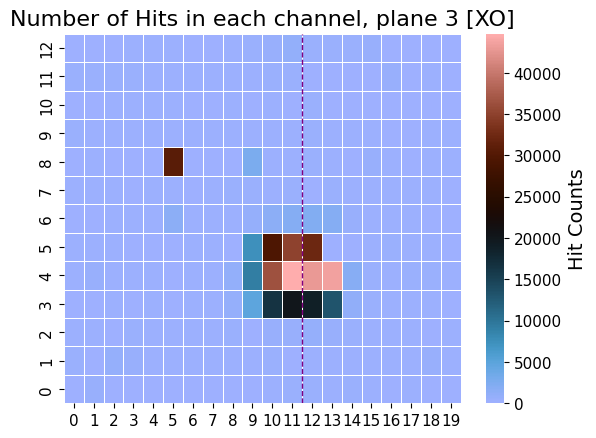

In [10]:
rf.hits_amount_colormap_single_plane(data_1491.hits,3)

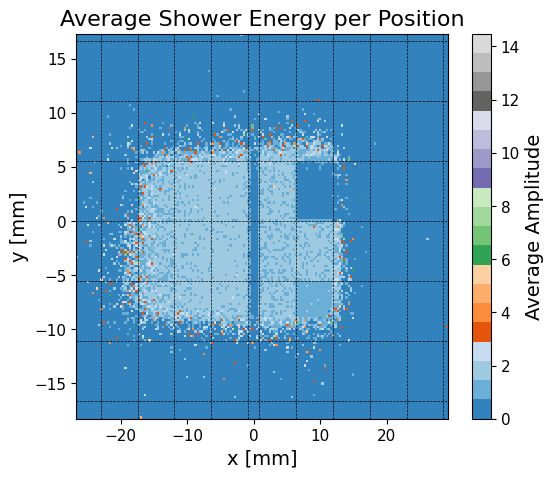

In [ ]:
x_borders = "false"
# x_borders = 10
y_borders = "false"

avg_energy_scope_colormap(data_1491, plane=2, x_center=0, y_center=-2, x_borders=x_borders, y_borders=y_borders, bins=170, cmap="tab20c", channels_borders = "all")
# avg_energy_scope_colormap(data_1491_filtered, plane=0, x_center=0, y_center=-2, x_borders=x_borders, y_borders=y_borders, bins=170, cmap="tab20c", channels_borders = "all", pad=91)

<span style="font-family: Comic Sans MS; font-size:15px; color:Purple">

# X Edge

Sigmoid fit parameters:
A     = 1.243
t    = -6.940
r = 31.436


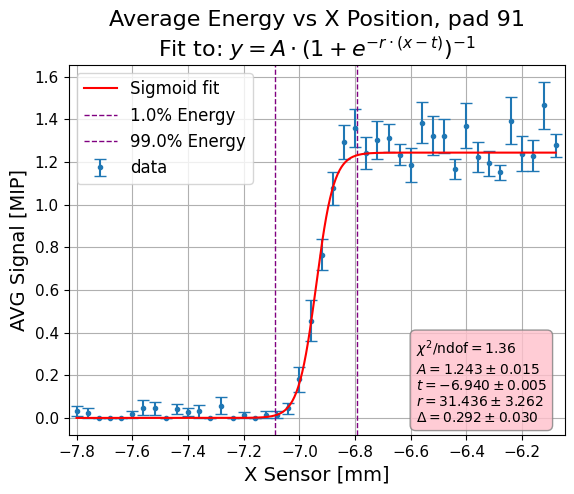

In [12]:
# pads edges analysis on X

# parameters
pad = 91
plane = 5
chi2 = 1.3
bin_size=0.04
low_E = 0.01  # amount of energy to determine the sigmoid borders
high_E = 1 - low_E
side = 0 # 0 for left edge, 1 for right

# get the pads edge
x_lines, y_lines = multiple_pad_edges_gridlines(pad)

# get the sigmoid data using pad edges
ymin = y_lines[0] + 1  # lower y bound
ymax = y_lines[1] - 1  # upper y bound
t_left1 = x_lines[side]    # initial center of the left edge sigmoid
t_right1 = x_lines[1]   # initial center of the right edge sigmoid
delta1 = 1              # initial width of data on x

popt, *_ = E_vs_X_scope_sigmoid(data_1491, chi2, plane, ymin, ymax,
                                                   t_left1-delta1, t_left1+delta1,
                                                   bin_size=bin_size,
                                                   pad=pad, low_E = low_E,
                                                   return_param=True)



# get the sigmoid data again using the fitted data
ymin = y_lines[0] + 1  # lower y bound
ymax = y_lines[1] - 1  # upper y bound
t = popt[1]            # center of sigmoid
r = popt[2]            # rate of sigmoid growth
delta = np.abs((2/r)*np.log(high_E/low_E))   # width of sigmoid
E_vs_X_scope_sigmoid(data_1491, chi2, plane, ymin, ymax,
                      t-3*delta, t+3*delta, bin_size=bin_size,
                        pad=pad, low_E = low_E, edges=False, ytext=0.26 + side*0.2)


# plot the data at the pad edge


<span style="font-family: Comic Sans MS; font-size:15px; color:orange">

## Pad Width

/Users/bentalmor/Desktop/LUXE/F-Cal-TB-Project/venv_2026/lib/python3.14/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))
/var/folders/2p/r6vn4j655dl2xqksw7_604y40000gp/T/ipykernel_70269/4068807380.py:48: RuntimeWarning: overflow encountered in exp
  return  A / (1.0 + np.exp(-(x - t) * r))
/Users/bentalmor/Desktop/LUXE/F-Cal-TB-Project/venv_2026/lib/python3.14/site-packages/scipy/optimize/_minpack_py.py:989: RuntimeWarning: divide by zero encountered in divide
  transform = 1.0 / sigma
/var/folders/2p/r6vn4j655dl2xqksw7_604y40000gp/T/ipykernel_70269/1599389130.py:58: OptimizeWarning: Covariance of the parameters could not be estimated
  popt_91, pcov_91 = curve_fit(difference_of_sigmoids, pos_91, amp_91, p0=p0, sigma=err_91, absolute_sigma=True,maxfev=2000)
/var/folders/2p/r6vn4j655dl2xqksw7_604y40000gp/T/ipykernel_70269/1599389130.py:20: RuntimeWarning: overflow encountered in exp

5.833015173503514


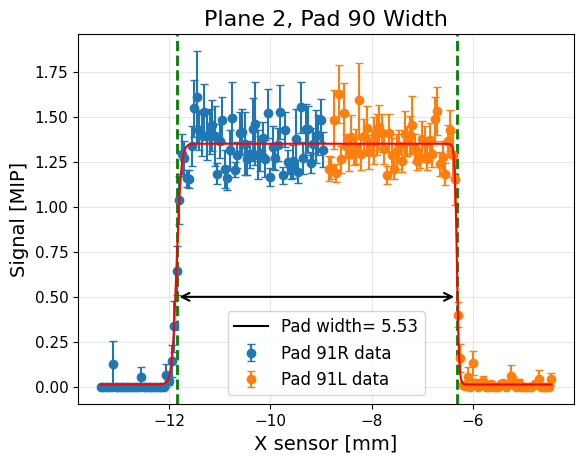

[13, -12, 10, -10, 5.53, 10] [-1.33663178e+00 -1.18489209e+01 -2.26973613e+01 -4.68724815e+01
  5.53252896e+00  1.33898456e-02]


In [19]:
# visualize the pad width from left to right pad 90

ymin = -5
t = -5
delta = 3
pad = 90
x_center = -8.9
x_lim = 4.5
bin_size=0.05

popt_91R, pos_m_91R, amp_m_91R, err_m_91R,_,_ = E_vs_X_scope_sigmoid(data_1491, 1.3, 2, ymin, ymin+3, t-2*delta, t+2*delta, bin_size=bin_size, pad=pad, return_param=True)

t = t-6
popt_91L, pos_m_91L, amp_m_91L, err_m_91L,_,_ = E_vs_X_scope_sigmoid(data_1491, 1.3, 2, ymin, ymin+3, t-2*delta, t+2*delta, bin_size=bin_size, pad=pad, return_param=True)



def difference_of_sigmoids(x, A, t, r1, r2, d, c):
    # Sigmoid 1 (Rising edge)
    sig1 = 1 / (1 + np.exp(-r1 * (x - t)))
    # Sigmoid 2 (Falling edge, shifted by d)
    sig2 = 1 / (1 + np.exp(-r2 * (x - (t + d))))
    # The difference creates a bump with height A
    return A * (sig1 - sig2) + c

# fit the double sigmoid to the data

# mask the X values for the wanted range
mask_91R = (pos_m_91R > x_center-x_lim) & (pos_m_91R < x_center)
mask_91L = (pos_m_91L > x_center) & (pos_m_91L < x_center+x_lim)

pos_91R, amp_91R, err_91R = pos_m_91R[mask_91R], amp_m_91R[mask_91R], err_m_91R[mask_91R]
pos_91L, amp_91L, err_91L = pos_m_91L[mask_91L], amp_m_91L[mask_91L], err_m_91L[mask_91L]

# unify (right + left)
pos_91 = np.concatenate([ak.to_numpy(pos_91R), ak.to_numpy(pos_91L)])
amp_91 = np.concatenate([ak.to_numpy(amp_91R), ak.to_numpy(amp_91L)])
err_91 = np.concatenate([ak.to_numpy(err_91R), ak.to_numpy(err_91L)])


# 2. Re-order all three arrays using those indices
sort_idx = np.argsort(pos_91)
pos_91 = pos_91[sort_idx]
amp_91 = amp_91[sort_idx]
err_91 = err_91[sort_idx]

"fit to double sigmoid"
# initial guesses (tune as needed)
A0 = 13
t0 = -12
r10 = 10
r20 = -10
d0 = 5.53
c0 = 10
p0 = [A0, t0, r10, r20, d0, c0]

# popt_91, pcov_91 = curve_fit(double_sigmoid, pos_91, amp_91, p0=p0, sigma=err_91, absolute_sigma=True,maxfev=2000)
popt_91, pcov_91 = curve_fit(difference_of_sigmoids, pos_91, amp_91, p0=p0, sigma=err_91, absolute_sigma=True,maxfev=2000)
popt_91, pcov_91 = curve_fit(difference_of_sigmoids, pos_91, amp_91, p0=p0, absolute_sigma=True,maxfev=2000)
perr_91 = np.sqrt(np.diag(pcov_91))  # 1σ parameter errors

A_fit, t_fit, r1_fit, r2_fit, d_fit, c_fit = popt_91


# create a smooth sigmoid for the fitted data
x_fit_91 = np.linspace(min(pos_91), max(pos_91), 500)
y_fit_91 = difference_of_sigmoids(x_fit_91, *popt_91)


'plot'
fig, ax = plt.subplots()


# data points with errors
ax.errorbar(pos_91R, amp_91R, yerr=err_91R, fmt='o', capsize=3, label='Pad 91R data')
ax.errorbar(pos_91L, amp_91L, yerr=err_91L, fmt='o', capsize=3, label='Pad 91L data')


# plot sigmoids
ax.plot(x_fit_91, y_fit_91, '-', color="red", zorder=7)


# determine the width of the sigmoids
low_E = 0.01
high_E = 1-low_E
delta_91R = (2/r2_fit)*np.log(high_E/low_E)
delta_91L = (2/r1_fit)*np.log(high_E/low_E)
pad_width = np.abs(d_fit)

# vertical lines for the energy drops
'91R'
plt.axvline(x=t_fit, color='green', linestyle='--', linewidth=2)#, label=f"{high_E}A pad 91R")

'91L'
plt.axvline(x= t_fit + pad_width, color='green', linestyle='--', linewidth=2)#, label=f"{low_E}A pad 91L")

# arrow with gap width
arr = ax.annotate("", xy=(t_fit, 0.5), xytext=(t_fit+pad_width, 0.5),
    arrowprops=dict(arrowstyle="<->", lw=1.5))

# add notations of the pad width to the legend
ax.plot([], [], color='black', lw=1.5, label=f"Pad width={pad_width: .2f}")

ax.set_xlabel("X sensor [mm]")
ax.set_ylabel("Signal [MIP]")
ax.set_title("Plane 2, Pad 90 Width")
ax.legend()
ax.grid(True, alpha=0.3)

print(np.abs(t_fit + delta_91L/2 - (t_fit + pad_width - delta_91R/2)))

plt.show()

print(p0, popt_91)


In [20]:
# get the pad width for all pads

def pad_width_sigmoid(data,plane, pad, chi2=2, low_E=0.1, bin_size=0.02, right=False, y_slice=3):
    " takes a pad and plane and calculates the width on the x axis: "
    " (distance between centers of the sigmoid)"
    t_list = []
    t_err_list = []

    # get the center of the sigmoids for both sides of the pad
    for side in range(2):  # side = 0 is left, 1 is right
        popt, perr, *_ = pad_edge_sigmoid(data, plane, pad, chi2=2, low_E=0.1, bin_size=0.02, right=side, y_slice=3, return_perr=True)
        t = popt[1]
        t_err = perr[1]
        t_list.append(t)
        t_err_list.append(t_err)
    
    # calculate the width and uncertainty
    width = t_list[1] - t_list[0]
    width_err = t_err_list[0] + t_err_list[1]


    return width , width_err

In [21]:
def multiple_pads_width(data, plane_list, pads_list, err_max = 1, chi2=2, low_E=0.1, bin_size=0.02, right=False, y_slice=3):
    "takes a list of pads and plots the width of each one"

    pad_list = []
    width_list = []
    width_err_list = []

    # get the width and errors for all pad
    for plane in plane_list:
        plane_pad_list = []
        pad_width_list = []
        pad_width_err_list = []

        for pad in pads_list:
            try:
                pad_width, pad_width_err = pad_width_sigmoid(data,plane,pad)
                if (pad_width_err < err_max) & (pad_width > 1):
                    plane_pad_list.append(pad)
                    pad_width_list.append(pad_width)
                    pad_width_err_list.append(pad_width_err)
            
            except Exception:
                continue
        
        pad_list.append(plane_pad_list)
        width_list.append(pad_width_list)
        width_err_list.append(pad_width_err_list)





    # Plot

    fig, ax = plt.subplots(figsize=(12, 6))

    offset = 0
    all_xticks = []
    all_labels = []

    # collect ALL points for global fit
    x_all = []
    y_all = []
    yerr_all = []

    for plane, pads_ok, y, yerr in zip(plane_list, pad_list, width_list, width_err_list):
        y = np.asarray(y, dtype=float)
        yerr = np.asarray(yerr, dtype=float)

        n = len(pads_ok)
        x = offset + np.arange(n)

        ax.errorbar(x, y, yerr=yerr, fmt='o', capsize=4, label=f"plane {plane}")

        # ticks/labels
        all_xticks.append(x)
        all_labels.append(np.asarray(pads_ok).astype(str))

        # global fit collectors
        x_all.append(x)
        y_all.append(y)
        yerr_all.append(yerr)

        offset += n

    # flatten
    all_xticks = np.concatenate(all_xticks) if all_xticks else np.array([])
    all_labels = np.concatenate(all_labels) if all_labels else np.array([])

    x_all = np.concatenate(x_all) if x_all else np.array([])
    y_all = np.concatenate(y_all) if y_all else np.array([])
    yerr_all = np.concatenate(yerr_all) if yerr_all else np.array([])

    # --- GLOBAL constant fit (weighted mean) ---
    good = np.isfinite(y_all) & np.isfinite(yerr_all) & (yerr_all > 0)
    if np.any(good):
        w = 1.0 / (yerr_all[good] ** 2)
        c = np.sum(w * y_all[good]) / np.sum(w)
        c_err = np.sqrt(1.0 / np.sum(w))
        chi2_val = np.sum(((y_all[good] - c) / yerr_all[good]) ** 2)
        ndf = int(np.sum(good) - 1)

        # draw one line across the whole plot
    ax.axhline(c, linestyle='-', color='red', linewidth=2, label='Fit to Const')

            
    ax.text(
        0.03, 0.05,
        f"Fit to Const:\n"
        f"c = {c:.4g} ± {c_err:.1g}\n"
        f"χ²/ndf = {(chi2_val / ndf) :.2g}",
        transform=ax.transAxes,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            alpha=0.8,
            edgecolor="black",))

    # set xticks
    if all_xticks.size:
        ax.set_xticks(all_xticks, labels=all_labels, rotation=45, ha='right')

    ax.set_xlabel("Pad Number")
    ax.set_ylabel("Width [mm]")
    ax.set_title("Pads X Widths")
    ax.grid(True, alpha=0.3)
    ax.legend(loc = (1.02,0.26), fontsize=10)

    plt.tight_layout()
    plt.show()


/var/folders/2p/r6vn4j655dl2xqksw7_604y40000gp/T/ipykernel_70269/4068807380.py:48: RuntimeWarning: overflow encountered in exp
  return  A / (1.0 + np.exp(-(x - t) * r))
/var/folders/2p/r6vn4j655dl2xqksw7_604y40000gp/T/ipykernel_70269/4068807380.py:63: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(sigmoid_linear, pos_m, amp_m, p0=[A0, t0, r0], sigma=np.where(err_m > 0, err_m, 1.0),


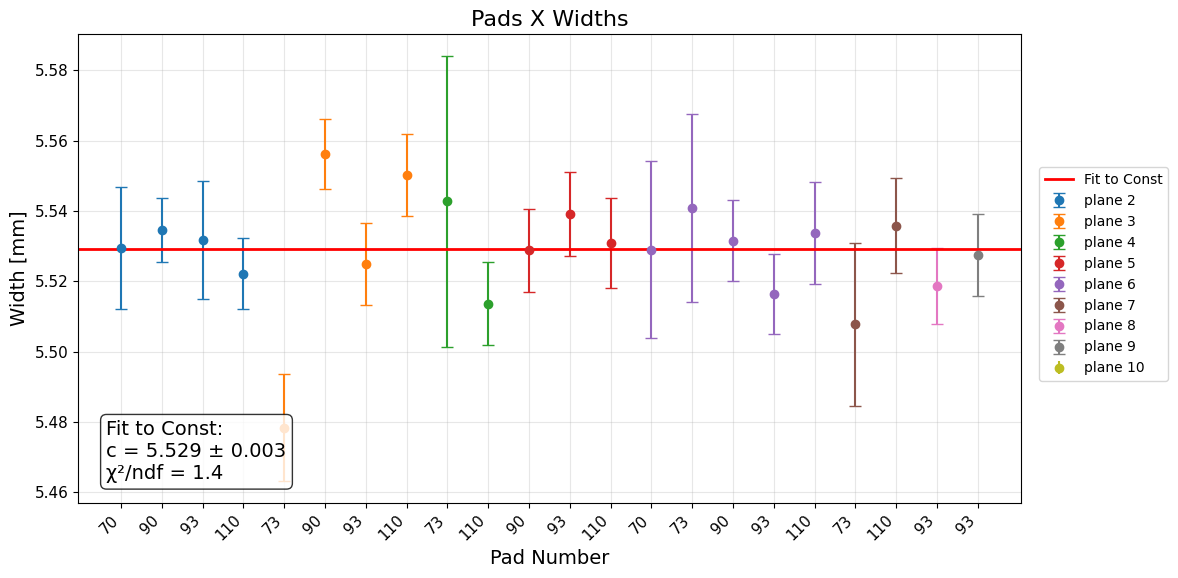

In [22]:
# OFF gap
multiple_pads_width(data_1491, plane_list = [2,3,4,5,6,7,8,9,10], pads_list=[70,73,90,93,110], err_max=1)
# multiple_pads_width(data_1491, plane_list = [2,3], pads_list=[70,73], err_max=1)

/Users/bentalmor/Desktop/LUXE/F-Cal-TB-Project/venv_2026/lib/python3.14/site-packages/awkward/_nplikes/array_module.py:289: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))
/var/folders/2p/r6vn4j655dl2xqksw7_604y40000gp/T/ipykernel_70269/4068807380.py:48: RuntimeWarning: overflow encountered in exp
  return  A / (1.0 + np.exp(-(x - t) * r))
/var/folders/2p/r6vn4j655dl2xqksw7_604y40000gp/T/ipykernel_70269/4068807380.py:63: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(sigmoid_linear, pos_m, amp_m, p0=[A0, t0, r0], sigma=np.where(err_m > 0, err_m, 1.0),


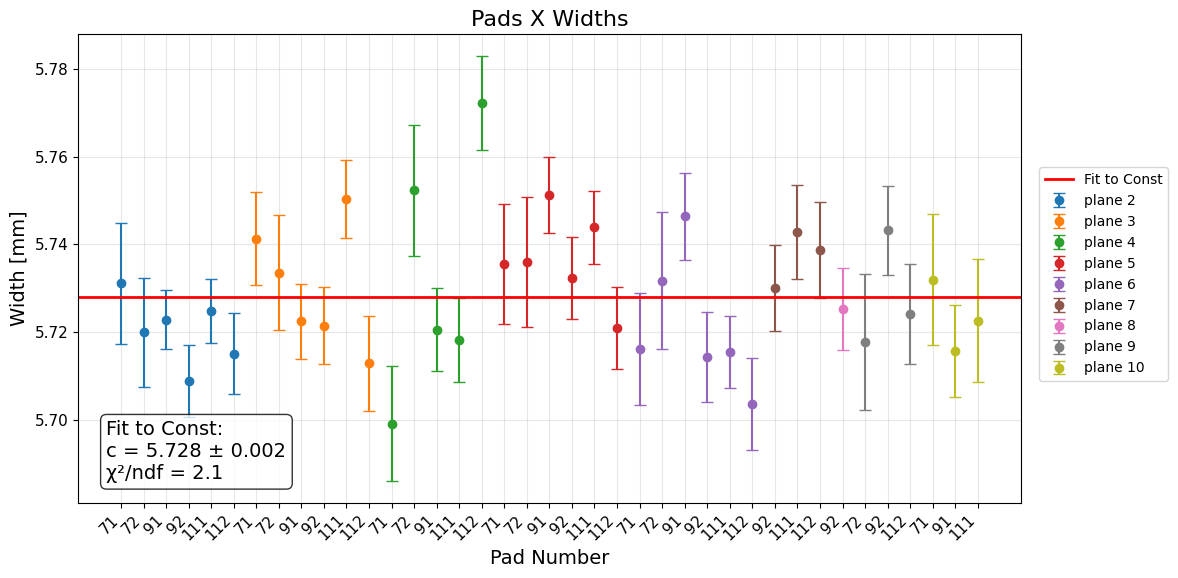

In [23]:
# ON gap
multiple_pads_width(data_1491,plane_list = [2,3,4,5,6,7,8,9,10], pads_list=[71,72,91,92,111,112])